# Sequential Quadratic Programming (SQP)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L09/L09_sqp.ipynb)
### MECH 559 - Systems Optimization - L09

Companion notebook to the "Algorithms for nonlinearly constrained optimization" lecture, in two parts. Part 1 implements the **Lagrange-Newton equations** directly for an equality-constrained problem and verifies the promised *quadratic* local convergence rate. Part 2 builds a full inequality-constrained **SQP** solver - a sequence of QP subproblems, each solved with the active-set method from `L09_active_set_method.ipynb` - and applies it to the four-constraint example the slides point to.

## Learning objectives

By the end, students should be able to:

1. Assemble $W_k=\nabla_x^2f_k+\lambda^\mathsf{T}\nabla_x^2h_k$ and $A_k=\nabla_xh_k$ and solve the Lagrange-Newton system for $(\partial x_k,\lambda_{k+1})$.
2. Verify numerically that full Newton on the KKT system converges quadratically, and that this is the same convergence-rate definition used in `L09_convergence_and_termination.ipynb`.
3. Recognize that the QP subproblem $\min\tfrac12\partial x^\mathsf{T}W\partial x+\nabla f^\mathsf{T}\partial x$ s.t. linearized constraints, solved by active-set, *is* one SQP iteration for inequality constraints.
4. Run SQP to convergence on a 4-constraint NLP and cross-check against `scipy.optimize.minimize(method="SLSQP")`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"sqp": "#1D5FA8", "optimum": "#2A9D5C", "feasible": "#A8DADC"}
print(f"NumPy {np.__version__}, SciPy ok")

NumPy 2.5.0, SciPy ok


---
## Part 1 - Lagrange-Newton on an equality-constrained problem

Reusing the circle example from `L09_generalized_reduced_gradient.ipynb`:

$$
\min_{x_1,x_2}\; f(x)=(x_1-2)^2+(x_2-2)^2 \qquad\text{s.t.}\qquad h(x)=x_1^2+x_2^2-1=0.
$$

$\nabla^2f=2I$, $\nabla^2h=2I$, so $W_k=(2+2\lambda_k)I$ and $A_k=\nabla h_k=[2x_1,\,2x_2]$. Each iteration solves the bordered linear system

$$
\begin{bmatrix}W_k & A_k^\mathsf{T}\\ A_k & 0\end{bmatrix}
\begin{bmatrix}\partial x_k\\ \lambda_{k+1}\end{bmatrix}
=
\begin{bmatrix}-\nabla f_k\\ -h_k\end{bmatrix}
$$

for the *full* Newton step - no line search, no trust region, just the raw Lagrange-Newton update.

In [3]:
def f1(x):
    return (x[0] - 2.0) ** 2 + (x[1] - 2.0) ** 2

def grad_f1(x):
    return np.array([2.0 * (x[0] - 2.0), 2.0 * (x[1] - 2.0)])

def h1(x):
    return x[0] ** 2 + x[1] ** 2 - 1.0

def grad_h1(x):
    return np.array([2.0 * x[0], 2.0 * x[1]])

def lagrange_newton(x0, lam0=0.0, max_iter=15, tol=1e-13):
    x = np.array(x0, dtype=float)
    lam = lam0
    traj = [x.copy()]
    for _ in range(max_iter):
        W = (2.0 + 2.0 * lam) * np.eye(2)
        A = grad_h1(x).reshape(1, 2)
        KKT = np.block([[W, A.T], [A, np.zeros((1, 1))]])
        rhs = np.concatenate([-grad_f1(x), [-h1(x)]])
        sol = np.linalg.solve(KKT, rhs)
        dx, lam = sol[:2], sol[2]
        x = x + dx
        traj.append(x.copy())
        if np.linalg.norm(dx) < tol:
            break
    return np.array(traj), lam

ln_traj, lam_star = lagrange_newton(x0=[0.0, 1.0])
x_star1 = np.array([1.0, 1.0]) / np.sqrt(2.0)
print(f"Lagrange-Newton converged in {len(ln_traj) - 1} iterations")
print(f"x* = {ln_traj[-1]}, analytic = {x_star1}, lambda* = {lam_star:.6f}")

Lagrange-Newton converged in 8 iterations
x* = [0.70710678 0.70710678], analytic = [0.70710678 0.70710678], lambda* = 1.828427


iteration errors ||x_k - x*||:
  k=0: 7.654e-01
  k=1: 1.326e+00
  k=2: 4.142e-01
  k=3: 6.066e-02
  k=4: 1.735e-03
  k=5: 1.502e-06
  k=6: 1.128e-12
  k=7: 1.570e-16
  k=8: 0.000e+00

e_(k+1)/e_k^2 ratios (should settle to a constant for quadratic convergence): [2.263  0.2357 0.3536 0.4714 0.4991 0.5   ]


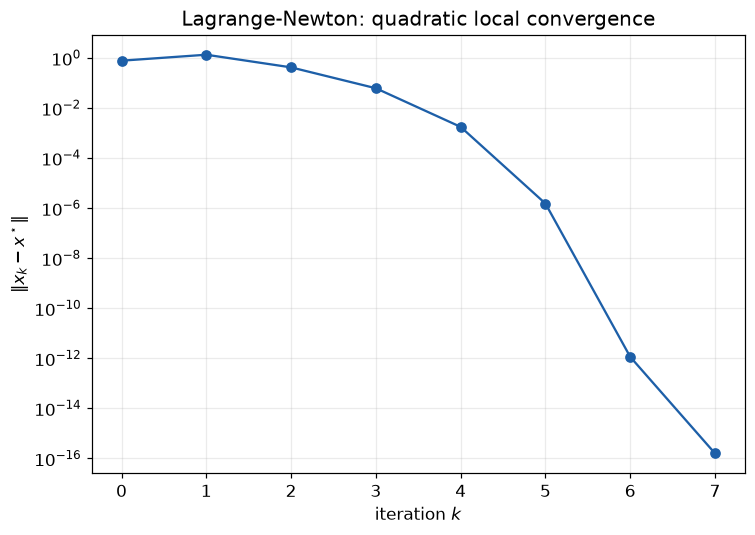

In [4]:
errs = np.linalg.norm(ln_traj - x_star1, axis=1)
valid = errs > 1e-9     # drop the floating-point noise floor (errs below ~1e-9 are just roundoff)
ratios = errs[1:][valid[:-1]] / errs[:-1][valid[:-1]] ** 2

print("iteration errors ||x_k - x*||:")
for k, e in enumerate(errs):
    print(f"  k={k}: {e:.3e}")
print(f"\ne_(k+1)/e_k^2 ratios (should settle to a constant for quadratic convergence): {np.round(ratios, 4)}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(errs[errs > 1e-16], "-o", color=COLORS["sqp"])
ax.set(xlabel="iteration $k$", ylabel=r"$\|x_k-x^\star\|$", title="Lagrange-Newton: quadratic local convergence")
plt.tight_layout()
plt.show()

Note the *first* step actually moves further from $x^\star$: full Newton is not globally convergent, it only converges quadratically once close enough to the solution (this is exactly why practical SQP codes add a line search or trust region around the Lagrange-Newton step). Once in the quadratic regime the number of correct digits roughly doubles every iteration, and the ratio $e_{k+1}/e_k^2$ settles to a constant - compare this to the *linear* convergence of GRG's steepest-descent outer loop in `L09_generalized_reduced_gradient.ipynb` (see also `L09_convergence_and_termination.ipynb`).

---
## Part 2 - Full SQP with inequality constraints

We now build the general algorithm from the "SQP algorithm principle" slide: at each iterate, form the QP

$$
\min_{\partial x}\; \tfrac12\partial x^\mathsf{T}W_k\partial x+\nabla f_k^\mathsf{T}\partial x
\qquad\text{s.t.}\qquad
\nabla g_i(x_k)^\mathsf{T}\partial x + g_i(x_k) \le 0,\ i=1,\dots,m,
$$

solve it with the **active-set method** (linear KKT solves + add/drop, exactly as in `L09_active_set_method.ipynb`), take a step along $\partial x_k$ (backtracked with an $\ell_1$ merit function for global progress), and repeat.

In [5]:
def solve_equality_kkt(H, c, A, b, working_set):
    # Solve the KKT system for 0.5 dx^T H dx + c^T dx  s.t.  a_i^T dx = b_i, i in working_set.
    n = H.shape[0]
    idx = list(working_set)
    if not idx:
        return np.linalg.solve(H, -c), {}
    Aw, bw = A[idx], b[idx]
    m = len(idx)
    KKT = np.block([[H, Aw.T], [Aw, np.zeros((m, m))]])
    rhs = np.concatenate([-c, bw])
    sol = np.linalg.solve(KKT, rhs)
    return sol[:n], dict(zip(idx, sol[n:]))


def solve_qp_active_set(H, c, A, b, working_set0, max_iter=30):
    # QP: min 0.5 dx^T H dx + c^T dx  s.t.  A dx <= b.  Active-set method (add/drop one at a time).
    m = A.shape[0]
    working = set(working_set0)
    for _ in range(max_iter):
        dx, mu = solve_equality_kkt(H, c, A, b, working)
        residual = A @ dx - b
        candidates = [j for j in range(m) if j not in working]
        violated = [j for j in candidates if residual[j] > 1e-10]
        negative_mu = [i for i in working if mu[i] < -1e-10]
        if not violated and not negative_mu:
            return dx, mu
        if violated:
            working.add(violated[np.argmax(residual[violated])])
        elif negative_mu:
            working.remove(min(negative_mu, key=lambda i: mu[i]))
    raise RuntimeError("inner QP active-set method did not converge")

### The example NLP

$$
\min_{x_1,x_2}\; f(\mathbf x)=x_1^2+(x_2-1)^2
$$
$$
g_1=x_2-\tfrac15x_1^2\le0,\quad g_2=2x_1+3x_2-10\le0,\quad g_3=-5x_1-2x_2+2\le0,\quad g_4=-2x_1+7x_2-8\le0.
$$

Only $g_1$ is nonlinear, so $W_k=\nabla^2f+\lambda_1\nabla^2g_1=\begin{bmatrix}2-0.4\lambda_1&0\\0&2\end{bmatrix}$; the other constraints are linear and contribute no curvature.

In [6]:
def f2(x):
    return x[0] ** 2 + (x[1] - 1.0) ** 2

def grad_f2(x):
    return np.array([2.0 * x[0], 2.0 * (x[1] - 1.0)])

def gvec(x):
    return np.array([
        x[1] - x[0] ** 2 / 5.0,
        2.0 * x[0] + 3.0 * x[1] - 10.0,
        -5.0 * x[0] - 2.0 * x[1] + 2.0,
        -2.0 * x[0] + 7.0 * x[1] - 8.0,
    ])

def jac_g(x):
    return np.array([
        [-2.0 * x[0] / 5.0, 1.0],
        [2.0, 3.0],
        [-5.0, -2.0],
        [-2.0, 7.0],
    ])

def sqp(x0, max_iter=30, tol=1e-8, merit_weight=10.0):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    lam = {}
    for k in range(max_iter):
        gk, Ak = gvec(x), jac_g(x)
        lam1 = lam.get(0, 0.0)
        Wk = np.array([[2.0 - 0.4 * lam1, 0.0], [0.0, 2.0]])
        active_guess = {i for i in range(4) if gk[i] > -1e-6}
        dx, mu = solve_qp_active_set(Wk, grad_f2(x), Ak, -gk, active_guess)
        if np.linalg.norm(dx) < tol:
            break

        def merit(xx):
            return f2(xx) + merit_weight * np.sum(np.maximum(0.0, gvec(xx)))

        t, m0 = 1.0, merit(x)
        for _ in range(30):
            x_trial = x + t * dx
            if merit(x_trial) < m0:
                break
            t *= 0.5
        x = x_trial
        lam = mu
        traj.append(x.copy())
    return np.array(traj), lam

sqp_traj, sqp_lam = sqp(x0=[0.0, 0.0])
print(f"SQP converged in {len(sqp_traj) - 1} iterations")
print(f"x* = {sqp_traj[-1]}, f* = {f2(sqp_traj[-1]):.6f}")
print(f"g(x*) = {np.round(gvec(sqp_traj[-1]), 4)}")
lam_rounded = {i: round(v, 4) for i, v in sqp_lam.items()}
print(f"active multipliers = {lam_rounded}")

SQP converged in 3 iterations
x* = [0.38795902 0.03010244], f* = 1.091213
g(x*) = [-0.     -9.1338  0.     -8.5652]
active multipliers = {0: np.float64(2.1187), 2: np.float64(0.0894)}


### Cross-check against SLSQP and visualize

In [7]:
cons = [{"type": "ineq", "fun": (lambda x, i=i: -gvec(x)[i])} for i in range(4)]
res = minimize(f2, x0=[0.0, 0.0], constraints=cons, method="SLSQP")
print("hand-rolled SQP:", np.round(sqp_traj[-1], 6), " f =", f2(sqp_traj[-1]))
print("SLSQP          :", np.round(res.x, 6), " f =", res.fun)
assert np.allclose(sqp_traj[-1], res.x, atol=1e-4)
print("\nAgreement confirmed.")

hand-rolled SQP: [0.387959 0.030102]  f = 1.0912134794240158
SLSQP          : [0.387959 0.030102]  f = 1.0912134793737973

Agreement confirmed.


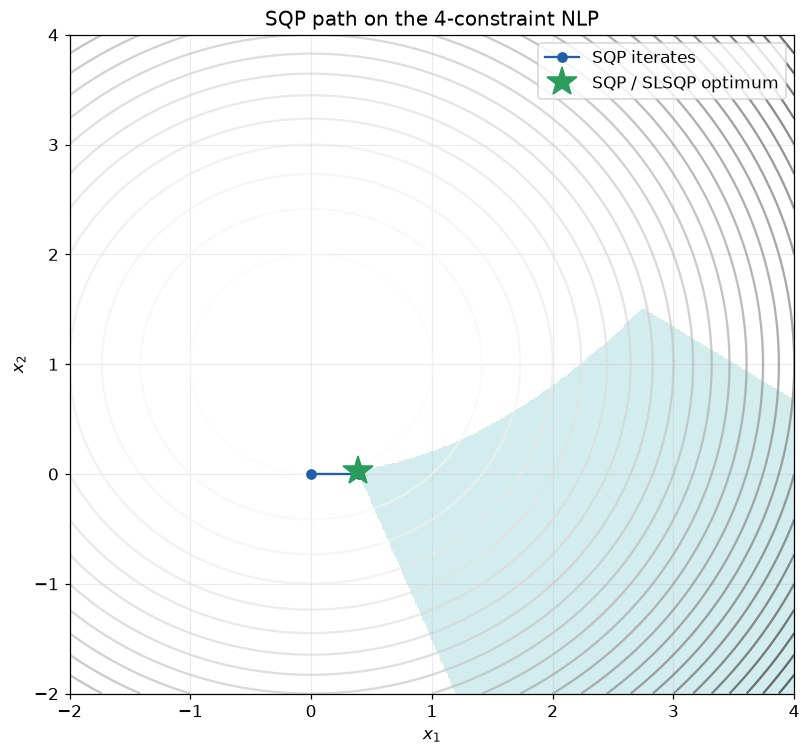

In [8]:
x1g, x2g = np.meshgrid(np.linspace(-2, 4, 400), np.linspace(-2, 4, 400))
Fg = x1g ** 2 + (x2g - 1.0) ** 2
feasible_mask = ((x2g - x1g ** 2 / 5.0 <= 0) & (2 * x1g + 3 * x2g - 10 <= 0) &
                  (-5 * x1g - 2 * x2g + 2 <= 0) & (-2 * x1g + 7 * x2g - 8 <= 0))

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.contourf(x1g, x2g, feasible_mask.astype(float), levels=[0.5, 1.5], colors=[COLORS["feasible"]], alpha=0.5)
ax.contour(x1g, x2g, Fg, levels=25, cmap="Greys", alpha=0.6)
ax.plot(sqp_traj[:, 0], sqp_traj[:, 1], "-o", color=COLORS["sqp"], ms=6, label="SQP iterates")
ax.plot(*sqp_traj[-1], "*", color=COLORS["optimum"], ms=20, label="SQP / SLSQP optimum")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="SQP path on the 4-constraint NLP", xlim=(-2, 4), ylim=(-2, 4))
ax.legend()
plt.tight_layout()
plt.show()

---
## Takeaways

1. Full Newton on the Lagrange-Newton (KKT) system converges **quadratically** once near the solution - the same $W_k\partial x_k+A_k^\mathsf{T}\lambda_{k+1}+\nabla f_k=0$ system reappears, unchanged, as the QP subproblem's own KKT conditions (that equivalence is the whole point of the slide's algebra).
2. For inequality constraints, one SQP iteration is exactly one **QP solve** (via active-set) using the linearized constraints at the current point - the QP's active set at each SQP iterate *is* the algorithm's guess of which constraints are active at the solution.
3. A raw full Newton / full QP step is not globally convergent (Part 1's first iterate moved *away* from the solution); practical SQP therefore backtracks the step with a merit function (used here) or uses a trust region, exactly as trust region was used to globalize Newton's method in `L06_trust_region.ipynb`.
4. The hand-rolled active-set SQP matches `scipy.optimize.minimize(method="SLSQP")` - which is itself an SQP implementation - to solver tolerance.